# Etapa 8 — Selección del threshold operativo y bloqueo final

## Objetivo

Convertir las probabilidades producidas por el modelo seleccionado  
`LogisticRegression_unweighted` en decisiones binarias reproducibles:

- `1`: se predice que el defensor generará presión.
- `0`: se predice que el defensor no generará presión.

## Regla de selección aprobada

El threshold se seleccionará utilizando exclusivamente el conjunto de validación correspondiente a la semana 7.

La regla formal será:

1. Seleccionar el threshold que maximice F1.
2. Si varios thresholds obtienen exactamente el mismo F1, elegir el threshold más alto para reducir el número de alertas sin sacrificar esa métrica.

F1 combina precision y recall mediante su media armónica:

- **Precision:** proporción de predicciones de presión que fueron correctas.
- **Recall:** proporción de presiones reales que el modelo logró detectar.

El threshold `0.5` se evaluará únicamente como referencia descriptiva y no como candidato automático.

## Restricciones vinculantes

- La semana 8 permanecerá sellada.
- No se construirán `X_test` ni `y_test`.
- No se utilizará test para seleccionar o ajustar el threshold.
- No se reentrenará ni modificará el modelo durante esta etapa.
- Se conservarán el pipeline, el preprocesamiento y el orden de variables aprobados.
- Se utilizarán exclusivamente el modelo y las predicciones cerradas de la Etapa 7.
- Toda decisión será reproducible y quedará registrada en artefactos auditables.

## Resultado esperado

La etapa concluirá con un threshold bloqueado, sus métricas de clasificación, un análisis de sensibilidad, una matriz de confusión y una política final lista para aplicarse una sola vez durante la evaluación de la semana 8.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

# ------------------------------------------------------------------
# Configuración reproducible
# ------------------------------------------------------------------

RANDOM_STATE = 42
TARGET_COLUMN = "pressure_actual"

np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:.6f}",
)

# ------------------------------------------------------------------
# Detección automática de la raíz del proyecto
# ------------------------------------------------------------------

start_path = Path.cwd().resolve()
candidate_roots = [start_path, *start_path.parents]

PROJECT_ROOT = next(
    (
        path
        for path in candidate_roots
        if (path / "models").is_dir()
        and (path / "reports").is_dir()
        and (path / "notebooks").is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "No fue posible identificar la raíz del proyecto. "
        "Abre el notebook desde la carpeta "
        "nfl-pressure-prediction."
    )

# ------------------------------------------------------------------
# Entradas cerradas de la Etapa 7
# ------------------------------------------------------------------

INPUT_PATHS = {
    "selected_model": (
        PROJECT_ROOT
        / "models"
        / "stage7_selected_model.joblib"
    ),
    "validation_predictions": (
        PROJECT_ROOT
        / "reports"
        / "stage7_validation_predictions.parquet"
    ),
    "stage7_quality_report": (
        PROJECT_ROOT
        / "reports"
        / "stage7_quality_report.csv"
    ),
}

missing_inputs = {
    name: path
    for name, path in INPUT_PATHS.items()
    if not path.is_file()
}

if missing_inputs:
    missing_text = "\n".join(
        f"- {name}: {path}"
        for name, path in missing_inputs.items()
    )

    raise FileNotFoundError(
        "Faltan artefactos requeridos de la Etapa 7:\n"
        f"{missing_text}"
    )

# ------------------------------------------------------------------
# Salidas aprobadas para la Etapa 8
# ------------------------------------------------------------------

OUTPUT_PATHS = {
    "threshold_metrics": (
        PROJECT_ROOT
        / "reports"
        / "stage8_threshold_metrics.csv"
    ),
    "threshold_sensitivity": (
        PROJECT_ROOT
        / "reports"
        / "stage8_threshold_sensitivity.csv"
    ),
    "validation_decisions": (
        PROJECT_ROOT
        / "reports"
        / "stage8_validation_decisions.parquet"
    ),
    "selected_policy": (
        PROJECT_ROOT
        / "reports"
        / "stage8_selected_policy.json"
    ),
    "quality_report": (
        PROJECT_ROOT
        / "reports"
        / "stage8_quality_report.csv"
    ),
}

print("STAGE 8 SETUP: PASS")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"joblib: {joblib.__version__}")
print(f"Validation target column: {TARGET_COLUMN}")

print("\nRequired Stage 7 inputs:")
for name, path in INPUT_PATHS.items():
    print(f"- {name}: FOUND -> {path.name}")

STAGE 8 SETUP: PASS
Project root: C:\Users\yvett\Downloads\nfl-pressure-prediction
Python: 3.14.0
NumPy: 2.5.2
pandas: 3.0.5
scikit-learn: 1.9.0
joblib: 1.5.3
Validation target column: pressure_actual

Required Stage 7 inputs:
- selected_model: FOUND -> stage7_selected_model.joblib
- validation_predictions: FOUND -> stage7_validation_predictions.parquet
- stage7_quality_report: FOUND -> stage7_quality_report.csv


In [2]:
# ------------------------------------------------------------------
# Carga exclusiva de artefactos cerrados de la Etapa 7
# ------------------------------------------------------------------

stage7_model = joblib.load(INPUT_PATHS["selected_model"])

validation_predictions = pd.read_parquet(
    INPUT_PATHS["validation_predictions"]
).copy()

stage7_quality_report = pd.read_csv(
    INPUT_PATHS["stage7_quality_report"]
).copy()

# ------------------------------------------------------------------
# Validación del modelo seleccionado
# ------------------------------------------------------------------

assert hasattr(stage7_model, "steps"), (
    "El modelo cargado no tiene la estructura esperada de un pipeline."
)

final_estimator = stage7_model.steps[-1][1]

assert final_estimator.__class__.__name__ == "LogisticRegression", (
    "El estimador final no es LogisticRegression."
)
assert final_estimator.class_weight is None, (
    "El modelo cargado utiliza ponderación de clases."
)
assert np.isclose(final_estimator.C, 1.0), (
    "El valor de C no coincide con el modelo aprobado."
)
assert final_estimator.solver == "lbfgs", (
    "El solver no coincide con el modelo aprobado."
)
assert final_estimator.max_iter == 2000, (
    "max_iter no coincide con el modelo aprobado."
)
assert final_estimator.random_state == RANDOM_STATE, (
    "random_state no coincide con el valor aprobado."
)

assert hasattr(stage7_model, "feature_names_in_"), (
    "El pipeline no conserva el orden original de variables."
)

model_feature_order = stage7_model.feature_names_in_.tolist()

assert len(model_feature_order) == 51, (
    f"Se esperaban 51 variables, pero el modelo contiene "
    f"{len(model_feature_order)}."
)
assert len(model_feature_order) == len(set(model_feature_order)), (
    "El orden almacenado contiene nombres de variables duplicados."
)

# ------------------------------------------------------------------
# Validación de las predicciones de la semana 7
# ------------------------------------------------------------------

required_prediction_columns = {
    "gameId",
    "playId",
    "pass_rusher_nfl_id",
    "actual_week",
    TARGET_COLUMN,
    "probability_logistic_regression",
}

missing_prediction_columns = (
    required_prediction_columns
    - set(validation_predictions.columns)
)

assert not missing_prediction_columns, (
    "Faltan columnas requeridas en las predicciones: "
    f"{sorted(missing_prediction_columns)}"
)

key_columns = [
    "gameId",
    "playId",
    "pass_rusher_nfl_id",
]

validation_weeks = sorted(
    validation_predictions["actual_week"]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

duplicate_keys = int(
    validation_predictions.duplicated(key_columns).sum()
)

validation_rows = len(validation_predictions)
validation_plays = (
    validation_predictions[["gameId", "playId"]]
    .drop_duplicates()
    .shape[0]
)
validation_positives = int(
    validation_predictions[TARGET_COLUMN].sum()
)

assert validation_weeks == [7], (
    f"Se encontraron semanas no autorizadas: {validation_weeks}"
)
assert validation_rows == 3_865, (
    f"Se esperaban 3,865 filas y se encontraron {validation_rows}."
)
assert validation_plays == 913, (
    f"Se esperaban 913 jugadas y se encontraron {validation_plays}."
)
assert validation_positives == 427, (
    f"Se esperaban 427 positivos y se encontraron "
    f"{validation_positives}."
)
assert duplicate_keys == 0, (
    f"Se encontraron {duplicate_keys} llaves duplicadas."
)

observed_classes = set(
    validation_predictions[TARGET_COLUMN]
    .dropna()
    .astype(int)
    .unique()
)

assert observed_classes == {0, 1}, (
    f"El target contiene clases inesperadas: {observed_classes}"
)

y_validation = (
    validation_predictions[TARGET_COLUMN]
    .astype(int)
    .to_numpy()
)

validation_probability = (
    validation_predictions["probability_logistic_regression"]
    .astype(float)
    .to_numpy()
)

assert np.isfinite(validation_probability).all(), (
    "Las probabilidades contienen valores no finitos."
)
assert (
    (validation_probability >= 0)
    & (validation_probability <= 1)
).all(), "Existen probabilidades fuera del intervalo [0, 1]."

# ------------------------------------------------------------------
# Reproducción de métricas cerradas
# ------------------------------------------------------------------

stage7_reproduced_metrics = {
    "average_precision": average_precision_score(
        y_validation,
        validation_probability,
    ),
    "roc_auc": roc_auc_score(
        y_validation,
        validation_probability,
    ),
    "log_loss": log_loss(
        y_validation,
        validation_probability,
        labels=[0, 1],
    ),
}

expected_stage7_metrics = {
    "average_precision": 0.151899,
    "roc_auc": 0.600006,
    "log_loss": 0.342382,
}

for metric_name, expected_value in expected_stage7_metrics.items():
    observed_value = stage7_reproduced_metrics[metric_name]

    assert np.isclose(
        observed_value,
        expected_value,
        atol=1e-6,
        rtol=0,
    ), (
        f"{metric_name} no se reprodujo: "
        f"observado={observed_value:.9f}, "
        f"esperado≈{expected_value:.6f}"
    )

# ------------------------------------------------------------------
# Validación del reporte de calidad cerrado
# ------------------------------------------------------------------

assert "status" in stage7_quality_report.columns, (
    "El reporte de calidad no contiene la columna status."
)
assert len(stage7_quality_report) == 16, (
    "El reporte de calidad no contiene los 16 controles esperados."
)

quality_pass_count = int(
    stage7_quality_report["status"]
    .astype(str)
    .str.upper()
    .eq("PASS")
    .sum()
)

assert quality_pass_count == 16, (
    f"Solo {quality_pass_count} de 16 controles están en PASS."
)

# ------------------------------------------------------------------
# Resumen auditable
# ------------------------------------------------------------------

print("STAGE 7 ARTIFACT VALIDATION: PASS")
print(f"Loaded object: {stage7_model.__class__.__name__}")
print(f"Final estimator: {final_estimator.__class__.__name__}")
print(f"Stored model features: {len(model_feature_order):,}")
print(f"Prediction table shape: {validation_predictions.shape}")
print(f"Weeks present: {validation_weeks}")
print(f"Validation plays: {validation_plays:,}")
print(f"Validation positives: {validation_positives:,}")
print(f"Duplicate rusher-play keys: {duplicate_keys}")
print(
    "Probability range: "
    f"[{validation_probability.min():.6f}, "
    f"{validation_probability.max():.6f}]"
)

print("\nReproduced Stage 7 metrics:")
for metric_name, metric_value in stage7_reproduced_metrics.items():
    print(f"- {metric_name}: {metric_value:.6f}")

print(
    f"\nStage 7 quality controls: "
    f"{quality_pass_count}/16 PASS"
)
print("WEEK 8 ACCESS: NOT PERFORMED")

STAGE 7 ARTIFACT VALIDATION: PASS
Loaded object: Pipeline
Final estimator: LogisticRegression
Stored model features: 51
Prediction table shape: (3865, 8)
Weeks present: [7]
Validation plays: 913
Validation positives: 427
Duplicate rusher-play keys: 0
Probability range: [0.028258, 0.449870]

Reproduced Stage 7 metrics:
- average_precision: 0.151899
- roc_auc: 0.600006
- log_loss: 0.342382

Stage 7 quality controls: 16/16 PASS
WEEK 8 ACCESS: NOT PERFORMED


In [3]:
# ------------------------------------------------------------------
# Construcción exhaustiva de candidatos de threshold
# ------------------------------------------------------------------

sort_order = np.argsort(
    validation_probability,
    kind="mergesort",
)

sorted_probability = validation_probability[sort_order]
sorted_target = y_validation[sort_order]

threshold_candidates, first_threshold_indices = np.unique(
    sorted_probability,
    return_index=True,
)

true_positives_by_row = np.cumsum(
    sorted_target[::-1],
    dtype=np.int64,
)[::-1]

false_positives_by_row = np.cumsum(
    (1 - sorted_target)[::-1],
    dtype=np.int64,
)[::-1]

true_positives = true_positives_by_row[
    first_threshold_indices
]
false_positives = false_positives_by_row[
    first_threshold_indices
]

total_positives = int(y_validation.sum())
total_negatives = int(len(y_validation) - total_positives)

false_negatives = total_positives - true_positives
true_negatives = total_negatives - false_positives

predicted_positives = true_positives + false_positives

threshold_precision = np.divide(
    true_positives,
    predicted_positives,
    out=np.zeros_like(true_positives, dtype=float),
    where=predicted_positives > 0,
)

threshold_recall = true_positives / total_positives
threshold_specificity = true_negatives / total_negatives

threshold_f1 = np.divide(
    2 * threshold_precision * threshold_recall,
    threshold_precision + threshold_recall,
    out=np.zeros_like(threshold_precision, dtype=float),
    where=(threshold_precision + threshold_recall) > 0,
)

predicted_positive_rate = predicted_positives / len(
    y_validation
)

threshold_metrics = pd.DataFrame(
    {
        "threshold": threshold_candidates,
        "true_negatives": true_negatives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "true_positives": true_positives,
        "precision": threshold_precision,
        "recall": threshold_recall,
        "f1": threshold_f1,
        "specificity": threshold_specificity,
        "predicted_positive_rate": predicted_positive_rate,
    }
)

# ------------------------------------------------------------------
# Verificación independiente mediante scikit-learn
# ------------------------------------------------------------------

(
    sklearn_precision,
    sklearn_recall,
    sklearn_thresholds,
) = precision_recall_curve(
    y_validation,
    validation_probability,
    drop_intermediate=False,
)

assert len(threshold_metrics) == len(
    np.unique(validation_probability)
), "No se evaluaron todos los thresholds únicos."

assert np.allclose(
    threshold_metrics["threshold"],
    sklearn_thresholds,
    atol=0,
    rtol=0,
), "Los thresholds no coinciden con scikit-learn."

assert np.allclose(
    threshold_metrics["precision"],
    sklearn_precision[:-1],
    atol=1e-12,
    rtol=0,
), "Precision no coincide con scikit-learn."

assert np.allclose(
    threshold_metrics["recall"],
    sklearn_recall[:-1],
    atol=1e-12,
    rtol=0,
), "Recall no coincide con scikit-learn."

row_totals = threshold_metrics[
    [
        "true_negatives",
        "false_positives",
        "false_negatives",
        "true_positives",
    ]
].sum(axis=1)

assert (row_totals == len(y_validation)).all(), (
    "Las matrices de confusión no conservan el total de filas."
)

# ------------------------------------------------------------------
# Regla aprobada: máximo F1 y threshold más alto ante empate
# ------------------------------------------------------------------

maximum_f1 = float(threshold_metrics["f1"].max())

f1_maximizer_mask = np.isclose(
    threshold_metrics["f1"],
    maximum_f1,
    atol=1e-12,
    rtol=0,
)

selected_threshold_index = threshold_metrics.loc[
    f1_maximizer_mask,
    "threshold",
].idxmax()

threshold_metrics["is_f1_maximizer"] = f1_maximizer_mask
threshold_metrics["is_selected"] = False
threshold_metrics.loc[
    selected_threshold_index,
    "is_selected",
] = True

selected_threshold_row = threshold_metrics.loc[
    selected_threshold_index
].copy()

selected_threshold = float(
    selected_threshold_row["threshold"]
)

selected_validation_class = (
    validation_probability >= selected_threshold
).astype(np.int8)

assert np.isclose(
    f1_score(y_validation, selected_validation_class),
    selected_threshold_row["f1"],
    atol=1e-12,
    rtol=0,
), "El F1 seleccionado no se reproduce mediante f1_score."

# ------------------------------------------------------------------
# Resultado preliminar de selección
# ------------------------------------------------------------------

print("THRESHOLD SEARCH: PASS")
print(f"Candidate thresholds evaluated: {len(threshold_metrics):,}")
print(f"Maximum F1 ties: {int(f1_maximizer_mask.sum()):,}")
print(f"Selected threshold: {selected_threshold:.12f}")
print(f"Precision: {selected_threshold_row['precision']:.6f}")
print(f"Recall: {selected_threshold_row['recall']:.6f}")
print(f"F1: {selected_threshold_row['f1']:.6f}")
print(
    "Specificity: "
    f"{selected_threshold_row['specificity']:.6f}"
)
print(
    "Predicted pressure rate: "
    f"{selected_threshold_row['predicted_positive_rate']:.6f}"
)
print(
    "Confusion counts — "
    f"TN={int(selected_threshold_row['true_negatives'])}, "
    f"FP={int(selected_threshold_row['false_positives'])}, "
    f"FN={int(selected_threshold_row['false_negatives'])}, "
    f"TP={int(selected_threshold_row['true_positives'])}"
)
print("WEEK 8 ACCESS: NOT PERFORMED")

THRESHOLD SEARCH: PASS
Candidate thresholds evaluated: 3,865
Maximum F1 ties: 1
Selected threshold: 0.124855148065
Precision: 0.154839
Recall: 0.505855
F1: 0.237102
Specificity: 0.657068
Predicted pressure rate: 0.360931
Confusion counts — TN=2259, FP=1179, FN=211, TP=216
WEEK 8 ACCESS: NOT PERFORMED


In [4]:
# ------------------------------------------------------------------
# Función reproducible para evaluar una política de threshold
# ------------------------------------------------------------------

def summarize_threshold_policy(
    policy_name,
    threshold,
    y_true,
    probability,
):
    predicted_class = (
        probability >= threshold
    ).astype(np.int8)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predicted_class,
        labels=[0, 1],
    ).ravel()

    specificity = tn / (tn + fp)

    return {
        "policy": policy_name,
        "threshold": float(threshold),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "precision": precision_score(
            y_true,
            predicted_class,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            predicted_class,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            predicted_class,
            zero_division=0,
        ),
        "specificity": specificity,
        "predicted_positive_count": int(
            predicted_class.sum()
        ),
        "predicted_positive_rate": float(
            predicted_class.mean()
        ),
        "actual_positive_rate": float(
            np.mean(y_true)
        ),
    }


REFERENCE_THRESHOLD = 0.5

threshold_policy_comparison = pd.DataFrame(
    [
        summarize_threshold_policy(
            policy_name="selected_max_f1",
            threshold=selected_threshold,
            y_true=y_validation,
            probability=validation_probability,
        ),
        summarize_threshold_policy(
            policy_name="reference_0_5",
            threshold=REFERENCE_THRESHOLD,
            y_true=y_validation,
            probability=validation_probability,
        ),
    ]
)

# ------------------------------------------------------------------
# Controles de consistencia
# ------------------------------------------------------------------

selected_comparison_row = (
    threshold_policy_comparison
    .loc[
        threshold_policy_comparison["policy"]
        == "selected_max_f1"
    ]
    .iloc[0]
)

reference_comparison_row = (
    threshold_policy_comparison
    .loc[
        threshold_policy_comparison["policy"]
        == "reference_0_5"
    ]
    .iloc[0]
)

for metric_name in [
    "precision",
    "recall",
    "f1",
    "specificity",
    "predicted_positive_rate",
]:
    assert np.isclose(
        selected_comparison_row[metric_name],
        selected_threshold_row[metric_name],
        atol=1e-12,
        rtol=0,
    ), (
        f"{metric_name} no coincide entre "
        "la búsqueda y la política seleccionada."
    )

assert REFERENCE_THRESHOLD > validation_probability.max(), (
    "El threshold 0.5 ya no está por encima de todas "
    "las probabilidades observadas."
)
assert reference_comparison_row[
    "predicted_positive_count"
] == 0, (
    "El threshold 0.5 produjo positivos inesperadamente."
)
assert reference_comparison_row["recall"] == 0, (
    "El recall de la referencia 0.5 debería ser cero."
)
assert reference_comparison_row["f1"] == 0, (
    "El F1 de la referencia 0.5 debería ser cero."
)

# ------------------------------------------------------------------
# Comparación final
# ------------------------------------------------------------------

print("THRESHOLD POLICY COMPARISON: PASS")
print(
    threshold_policy_comparison.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)
print("\nWEEK 8 ACCESS: NOT PERFORMED")

THRESHOLD POLICY COMPARISON: PASS
         policy  threshold  true_negatives  false_positives  false_negatives  true_positives  precision   recall       f1  specificity  predicted_positive_count  predicted_positive_rate  actual_positive_rate
selected_max_f1   0.124855            2259             1179              211             216   0.154839 0.505855 0.237102     0.657068                      1395                 0.360931              0.110479
  reference_0_5   0.500000            3438                0              427               0   0.000000 0.000000 0.000000     1.000000                         0                 0.000000              0.110479

WEEK 8 ACCESS: NOT PERFORMED


In [5]:
# ------------------------------------------------------------------
# Sensibilidad alrededor del threshold seleccionado
# ------------------------------------------------------------------

SENSITIVITY_MULTIPLIERS = np.array(
    [0.80, 0.90, 0.95, 1.00, 1.05, 1.10, 1.20],
    dtype=float,
)

sensitivity_records = []

for multiplier in SENSITIVITY_MULTIPLIERS:
    sensitivity_threshold = float(
        np.clip(
            selected_threshold * multiplier,
            0.0,
            1.0,
        )
    )

    policy_summary = summarize_threshold_policy(
        policy_name=f"sensitivity_{multiplier:.2f}",
        threshold=sensitivity_threshold,
        y_true=y_validation,
        probability=validation_probability,
    )

    policy_summary["threshold_multiplier"] = multiplier
    policy_summary["relative_change_pct"] = (
        multiplier - 1.0
    ) * 100
    policy_summary["is_selected"] = np.isclose(
        multiplier,
        1.0,
        atol=0,
        rtol=0,
    )

    sensitivity_records.append(policy_summary)

threshold_sensitivity = pd.DataFrame(
    sensitivity_records
).sort_values(
    "threshold",
    ignore_index=True,
)

# ------------------------------------------------------------------
# Cambios respecto de la política seleccionada
# ------------------------------------------------------------------

selected_sensitivity_row = (
    threshold_sensitivity
    .loc[threshold_sensitivity["is_selected"]]
    .iloc[0]
)

for metric_name in [
    "precision",
    "recall",
    "f1",
    "specificity",
    "predicted_positive_rate",
]:
    threshold_sensitivity[
        f"{metric_name}_delta"
    ] = (
        threshold_sensitivity[metric_name]
        - selected_sensitivity_row[metric_name]
    )

# ------------------------------------------------------------------
# Controles
# ------------------------------------------------------------------

assert len(threshold_sensitivity) == 7, (
    "No se construyeron los siete escenarios esperados."
)
assert threshold_sensitivity["is_selected"].sum() == 1, (
    "La política seleccionada no aparece exactamente una vez."
)
assert np.isclose(
    selected_sensitivity_row["threshold"],
    selected_threshold,
    atol=0,
    rtol=0,
), "El threshold central no coincide con el seleccionado."

assert (
    selected_sensitivity_row["f1"]
    >= threshold_sensitivity["f1"].max() - 1e-12
), (
    "Un escenario de sensibilidad superó inesperadamente "
    "el máximo global de F1."
)

# ------------------------------------------------------------------
# Tabla resumida
# ------------------------------------------------------------------

sensitivity_display_columns = [
    "relative_change_pct",
    "threshold",
    "false_positives",
    "false_negatives",
    "true_positives",
    "precision",
    "recall",
    "f1",
    "specificity",
    "predicted_positive_count",
    "predicted_positive_rate",
]

print("THRESHOLD SENSITIVITY: PASS")
print(
    threshold_sensitivity[
        sensitivity_display_columns
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)
print("\nSelected threshold remains unchanged.")
print("WEEK 8 ACCESS: NOT PERFORMED")

THRESHOLD SENSITIVITY: PASS
 relative_change_pct  threshold  false_positives  false_negatives  true_positives  precision   recall       f1  specificity  predicted_positive_count  predicted_positive_rate
          -20.000000   0.099884             2086              108             319   0.132640 0.747073 0.225282     0.393252                      2405                 0.622251
          -10.000000   0.112370             1628              164             263   0.139080 0.615925 0.226920     0.526469                      1891                 0.489263
           -5.000000   0.118612             1400              186             241   0.146862 0.564403 0.233075     0.592787                      1641                 0.424580
            0.000000   0.124855             1179              211             216   0.154839 0.505855 0.237102     0.657068                      1395                 0.360931
            5.000000   0.131098              997              244             183   0.155085 0.42

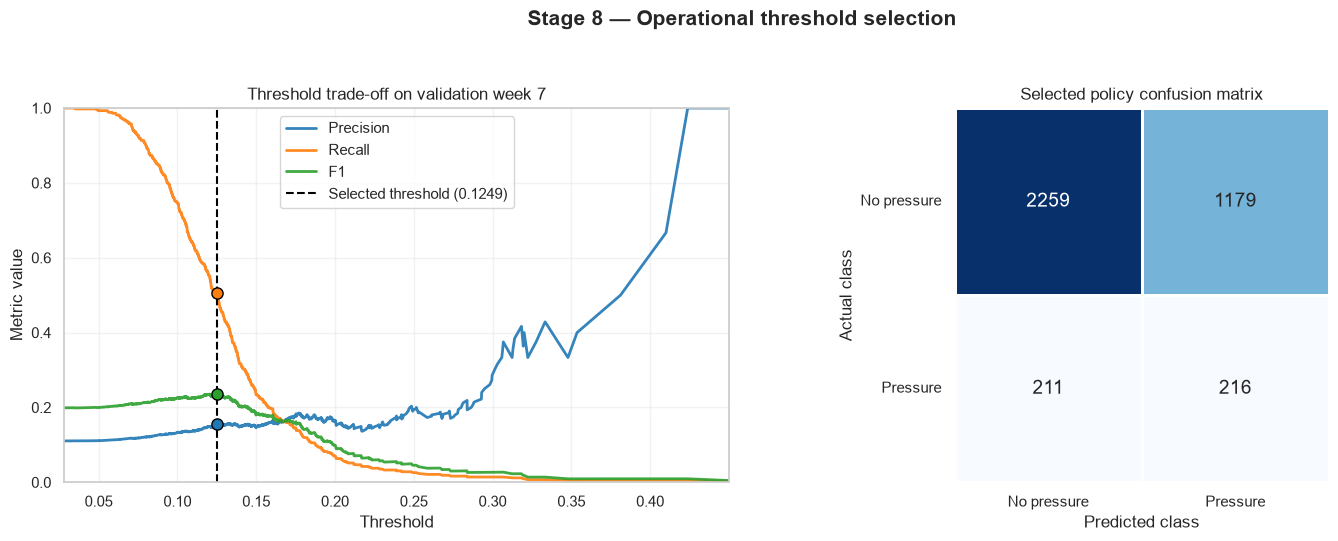

THRESHOLD VISUALIZATION: PASS
WEEK 8 ACCESS: NOT PERFORMED


In [6]:
# ------------------------------------------------------------------
# Matriz de confusión seleccionada
# ------------------------------------------------------------------

selected_confusion_matrix = confusion_matrix(
    y_validation,
    selected_validation_class,
    labels=[0, 1],
)

expected_selected_confusion_matrix = np.array(
    [
        [
            int(selected_threshold_row["true_negatives"]),
            int(selected_threshold_row["false_positives"]),
        ],
        [
            int(selected_threshold_row["false_negatives"]),
            int(selected_threshold_row["true_positives"]),
        ],
    ]
)

assert np.array_equal(
    selected_confusion_matrix,
    expected_selected_confusion_matrix,
), "La matriz de confusión no coincide con las métricas."

# ------------------------------------------------------------------
# Visualización
# ------------------------------------------------------------------

sns.set_theme(
    context="notebook",
    style="whitegrid",
)

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 5.5),
)

metric_colors = {
    "precision": "#1f77b4",
    "recall": "#ff7f0e",
    "f1": "#2ca02c",
}

for metric_name, metric_color in metric_colors.items():
    axes[0].plot(
        threshold_metrics["threshold"],
        threshold_metrics[metric_name],
        label=metric_name.replace("_", " ").title(),
        color=metric_color,
        linewidth=2,
        alpha=0.90,
    )

    axes[0].scatter(
        selected_threshold,
        selected_threshold_row[metric_name],
        color=metric_color,
        edgecolor="black",
        s=65,
        zorder=5,
    )

axes[0].axvline(
    selected_threshold,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=(
        "Selected threshold "
        f"({selected_threshold:.4f})"
    ),
)

axes[0].set_title(
    "Threshold trade-off on validation week 7"
)
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Metric value")
axes[0].set_xlim(
    threshold_metrics["threshold"].min(),
    threshold_metrics["threshold"].max(),
)
axes[0].set_ylim(0, 1)
axes[0].legend(loc="best")
axes[0].grid(alpha=0.25)

sns.heatmap(
    selected_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    linewidths=1,
    linecolor="white",
    annot_kws={"size": 14},
    ax=axes[1],
)

axes[1].set_title(
    "Selected policy confusion matrix"
)
axes[1].set_xlabel("Predicted class")
axes[1].set_ylabel("Actual class")
axes[1].set_xticklabels(
    ["No pressure", "Pressure"],
    rotation=0,
)
axes[1].set_yticklabels(
    ["No pressure", "Pressure"],
    rotation=0,
)

figure.suptitle(
    "Stage 8 — Operational threshold selection",
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

print("THRESHOLD VISUALIZATION: PASS")
print("WEEK 8 ACCESS: NOT PERFORMED")

## Interpretación de la política seleccionada

La regla aprobada seleccionó de manera única el threshold:

`0.124855148065`

Una observación se clasifica como presión cuando la probabilidad estimada por la regresión logística es mayor o igual a este valor.

### Resultados sobre validation — semana 7

- **Precision:** `15.484%`
- **Recall:** `50.585%`
- **F1:** `0.237102`
- **Especificidad:** `65.707%`
- **Porcentaje predicho como presión:** `36.093%`

La matriz de confusión contiene:

- **2,259 verdaderos negativos:** el modelo predijo correctamente que el defensor no generaría presión.
- **1,179 falsos positivos:** el modelo predijo presión, pero no ocurrió.
- **211 falsos negativos:** ocurrió presión, pero el modelo no la detectó.
- **216 verdaderos positivos:** el modelo predijo correctamente la presión.

En términos prácticos, la política detecta 216 de las 427 presiones reales de validation, aproximadamente la mitad. Sin embargo, solo 216 de sus 1,395 alertas corresponden a presiones reales. Esto demuestra que existe una separación predictiva moderada y que todavía hay un número considerable de falsas alertas.

### Comparación con el threshold 0.5

El threshold convencional de `0.5` queda por encima de la máxima probabilidad observada, `0.449870`. Por ello:

- Predice cero presiones.
- Obtiene recall igual a cero.
- Obtiene F1 igual a cero.
- Alcanza especificidad igual a uno únicamente porque clasifica todas las filas como negativas.

Este resultado confirma que `0.5` no constituye una política útil para este modelo y que métricas como accuracy o especificidad pueden ser engañosas cuando la clase positiva es poco frecuente.

### Sensibilidad

El análisis de sensibilidad confirma el intercambio esperado:

- Reducir el threshold aumenta el recall, pero también incrementa fuertemente las falsas alertas.
- Aumentar el threshold mejora la especificidad y reduce el número de alertas, pero pierde una mayor proporción de presiones reales.
- El threshold seleccionado conserva el mayor F1 entre todos los candidatos evaluados.

La selección se realizó exclusivamente con validation y mediante una regla definida antes de calcular los resultados. No representa una relación causal ni una política de producción basada en costos de negocio; constituye una política técnica neutral y reproducible para la evaluación final.

La semana 8 permanece sellada. El threshold no se modificará después de observar los resultados de test.

In [7]:
import hashlib


# ------------------------------------------------------------------
# Función para identificar exactamente un archivo
# ------------------------------------------------------------------

def calculate_sha256(file_path, chunk_size=1024 * 1024):
    sha256_hash = hashlib.sha256()

    with file_path.open("rb") as file:
        for chunk in iter(
            lambda: file.read(chunk_size),
            b"",
        ):
            sha256_hash.update(chunk)

    return sha256_hash.hexdigest()


source_artifact_hashes = {
    name: calculate_sha256(path)
    for name, path in INPUT_PATHS.items()
}

# ------------------------------------------------------------------
# Decisiones fila por fila sobre validation
# ------------------------------------------------------------------

validation_decisions = validation_predictions[
    [
        "actual_week",
        "gameId",
        "playId",
        "pass_rusher_nfl_id",
        TARGET_COLUMN,
        "probability_logistic_regression",
    ]
].copy()

validation_decisions["selected_threshold"] = (
    selected_threshold
)
validation_decisions["predicted_pressure"] = (
    selected_validation_class
)

actual_pressure = validation_decisions[
    TARGET_COLUMN
].to_numpy()

predicted_pressure = validation_decisions[
    "predicted_pressure"
].to_numpy()

classification_conditions = [
    (actual_pressure == 0) & (predicted_pressure == 0),
    (actual_pressure == 0) & (predicted_pressure == 1),
    (actual_pressure == 1) & (predicted_pressure == 0),
    (actual_pressure == 1) & (predicted_pressure == 1),
]

classification_labels = [
    "true_negative",
    "false_positive",
    "false_negative",
    "true_positive",
]

validation_decisions["classification_result"] = np.select(
    classification_conditions,
    classification_labels,
    default="invalid",
)

validation_decisions["prediction_correct"] = (
    actual_pressure == predicted_pressure
)

classification_counts = {
    str(name): int(count)
    for name, count in (
        validation_decisions["classification_result"]
        .value_counts()
        .to_dict()
        .items()
    )
}

expected_classification_counts = {
    "true_negative": 2259,
    "false_positive": 1179,
    "false_negative": 211,
    "true_positive": 216,
}

assert classification_counts == expected_classification_counts, (
    "Los resultados fila por fila no reproducen "
    "la matriz de confusión."
)
assert len(validation_decisions) == 3_865
assert validation_decisions.duplicated(key_columns).sum() == 0
assert validation_decisions["actual_week"].unique().tolist() == [7]
assert (
    validation_decisions["classification_result"]
    != "invalid"
).all()

# ------------------------------------------------------------------
# Contrato bloqueado de modelo, threshold y evaluación
# ------------------------------------------------------------------

locked_policy = {
    "schema_version": 1,
    "project": "nfl-pressure-prediction",
    "stage": 8,
    "status": "locked_before_test_evaluation",
    "week_8_status": "sealed_not_accessed",
    "source_artifacts": {
        name: {
            "path": path.relative_to(
                PROJECT_ROOT
            ).as_posix(),
            "sha256": source_artifact_hashes[name],
        }
        for name, path in INPUT_PATHS.items()
    },
    "target_contract": {
        "analytical_target": "pressure",
        "validation_artifact_target": TARGET_COLUMN,
        "positive_class": 1,
        "definition": (
            "pff_hurry OR pff_hit OR pff_sack"
        ),
    },
    "model_contract": {
        "selected_model": (
            "LogisticRegression_unweighted"
        ),
        "pipeline_class": (
            stage7_model.__class__.__name__
        ),
        "final_estimator_class": (
            final_estimator.__class__.__name__
        ),
        "numeric_predictor_count": 50,
        "categorical_predictors": [
            "rusher_position_lined_up"
        ],
        "total_predictor_count": 51,
        "ordered_feature_names": [
            str(feature_name)
            for feature_name in model_feature_order
        ],
        "preprocessing": {
            "numeric": "StandardScaler",
            "categorical": (
                "OneHotEncoder("
                "handle_unknown='ignore', "
                "sparse_output=False)"
            ),
        },
        "hyperparameters": {
            "C": float(final_estimator.C),
            "class_weight": final_estimator.class_weight,
            "solver": final_estimator.solver,
            "max_iter": int(final_estimator.max_iter),
            "random_state": int(
                final_estimator.random_state
            ),
        },
    },
    "threshold_contract": {
        "threshold": float(selected_threshold),
        "comparison_rule": (
            "probability >= threshold"
        ),
        "selection_dataset": "actual_week == 7",
        "selection_metric": "f1",
        "tie_break_rule": (
            "highest threshold among exact F1 ties"
        ),
        "candidate_threshold_count": int(
            len(threshold_metrics)
        ),
        "maximum_f1_tie_count": int(
            f1_maximizer_mask.sum()
        ),
        "reference_threshold": 0.5,
    },
    "validation_evidence": {
        "rows": int(validation_rows),
        "plays": int(validation_plays),
        "actual_positives": int(
            validation_positives
        ),
        "actual_positive_rate": float(
            y_validation.mean()
        ),
        "predicted_positives": int(
            selected_comparison_row[
                "predicted_positive_count"
            ]
        ),
        "predicted_positive_rate": float(
            selected_comparison_row[
                "predicted_positive_rate"
            ]
        ),
        "precision": float(
            selected_comparison_row["precision"]
        ),
        "recall": float(
            selected_comparison_row["recall"]
        ),
        "f1": float(
            selected_comparison_row["f1"]
        ),
        "specificity": float(
            selected_comparison_row["specificity"]
        ),
        "confusion_matrix": {
            "true_negatives": 2259,
            "false_positives": 1179,
            "false_negatives": 211,
            "true_positives": 216,
        },
    },
    "final_training_recipe": {
        "source_table": (
            "data/processed/"
            "pass_rush_analytical_table.parquet"
        ),
        "training_weeks": [1, 2, 3, 4, 5, 6, 7],
        "test_week": 8,
        "estimator_creation": (
            "sklearn.base.clone("
            "stage7_selected_model)"
        ),
        "feature_order_source": (
            "model_contract.ordered_feature_names"
        ),
        "target_column": "pressure",
        "fit_once": True,
        "random_state": RANDOM_STATE,
        "test_data_used_during_fit": False,
    },
    "final_evaluation_protocol": {
        "materialize_week_8_once": True,
        "probability_output": (
            "predict_proba(X_test)[:, 1]"
        ),
        "apply_locked_threshold": True,
        "probability_metrics": [
            "average_precision",
            "roc_auc",
            "log_loss",
        ],
        "threshold_metrics": [
            "precision",
            "recall",
            "f1",
            "specificity",
            "confusion_matrix",
            "predicted_positive_rate",
        ],
        "allow_model_changes_after_test": False,
        "allow_threshold_changes_after_test": False,
        "allow_feature_changes_after_test": False,
        "allow_calibration_after_test": False,
    },
    "software_versions": {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
    },
}

# Confirma que el contrato puede serializarse como JSON
locked_policy_json_preview = json.dumps(
    locked_policy,
    indent=2,
    sort_keys=True,
    ensure_ascii=False,
)

assert locked_policy["week_8_status"] == (
    "sealed_not_accessed"
)
assert locked_policy["threshold_contract"][
    "threshold"
] == selected_threshold
assert len(
    locked_policy["model_contract"][
        "ordered_feature_names"
    ]
) == 51

print("LOCKED POLICY CONSTRUCTION: PASS")
print(f"Validation decisions shape: {validation_decisions.shape}")
print(f"Classification counts: {classification_counts}")
print(f"Stored feature order: {len(model_feature_order)}")
print(f"Selected threshold: {selected_threshold:.12f}")
print(
    "Model SHA-256: "
    f"{source_artifact_hashes['selected_model']}"
)
print(
    "Prediction SHA-256: "
    f"{source_artifact_hashes['validation_predictions']}"
)
print("JSON serialization: PASS")
print("WEEK 8 ACCESS: NOT PERFORMED")

LOCKED POLICY CONSTRUCTION: PASS
Validation decisions shape: (3865, 10)
Classification counts: {'true_negative': 2259, 'false_positive': 1179, 'true_positive': 216, 'false_negative': 211}
Stored feature order: 51
Selected threshold: 0.124855148065
Model SHA-256: bbd5cf914cc56b3688ea55f44f79f683d954312a8346a54b13ac738c9be12a21
Prediction SHA-256: 57d2f95f6d7b668bf200cd4bfa63f488070505ba8e97d33e76c83e250da7a7d1
JSON serialization: PASS
WEEK 8 ACCESS: NOT PERFORMED


In [8]:
# ------------------------------------------------------------------
# Construcción del reporte de calidad de la Etapa 8
# ------------------------------------------------------------------

quality_check_records = []


def register_quality_check(
    check_id,
    area,
    condition,
    result,
    decision,
):
    quality_check_records.append(
        {
            "check_id": check_id,
            "area": area,
            "status": (
                "PASS" if bool(condition) else "FAIL"
            ),
            "result": str(result),
            "decision": str(decision),
        }
    )


valid_hash_characters = set("0123456789abcdef")

hashes_are_valid = all(
    len(file_hash) == 64
    and set(file_hash).issubset(
        valid_hash_characters
    )
    for file_hash in source_artifact_hashes.values()
)

materialized_test_objects = sorted(
    {"X_test", "y_test"}.intersection(globals())
)

register_quality_check(
    "ST8-01",
    "Input artifacts",
    all(path.is_file() for path in INPUT_PATHS.values()),
    f"{len(INPUT_PATHS)} required Stage 7 artifacts found",
    "Use only closed Stage 7 artifacts",
)

register_quality_check(
    "ST8-02",
    "Source integrity",
    hashes_are_valid,
    "SHA-256 generated for every source artifact",
    "Lock source identity before test",
)

register_quality_check(
    "ST8-03",
    "Prior quality",
    quality_pass_count == 16,
    f"{quality_pass_count}/16 Stage 7 controls PASS",
    "Accept the closed Stage 7 checkpoint",
)

register_quality_check(
    "ST8-04",
    "Model identity",
    (
        stage7_model.__class__.__name__ == "Pipeline"
        and final_estimator.__class__.__name__
        == "LogisticRegression"
        and final_estimator.class_weight is None
    ),
    "Pipeline with unweighted LogisticRegression",
    "Preserve the selected Stage 7 model family",
)

register_quality_check(
    "ST8-05",
    "Model parameters",
    (
        np.isclose(final_estimator.C, 1.0)
        and final_estimator.solver == "lbfgs"
        and final_estimator.max_iter == 2000
        and final_estimator.random_state
        == RANDOM_STATE
    ),
    (
        "C=1.0; solver=lbfgs; max_iter=2000; "
        f"random_state={RANDOM_STATE}"
    ),
    "Lock approved hyperparameters",
)

register_quality_check(
    "ST8-06",
    "Feature contract",
    (
        len(model_feature_order) == 51
        and len(set(model_feature_order)) == 51
        and locked_policy["model_contract"][
            "ordered_feature_names"
        ]
        == model_feature_order
    ),
    "51 unique predictors stored in model order",
    "Reuse this exact order during final evaluation",
)

register_quality_check(
    "ST8-07",
    "Temporal scope",
    validation_weeks == [7],
    f"Validation weeks present: {validation_weeks}",
    "Select threshold exclusively on week 7",
)

register_quality_check(
    "ST8-08",
    "Validation counts",
    (
        validation_rows == 3_865
        and validation_plays == 913
        and validation_positives == 427
    ),
    (
        f"{validation_rows:,} rows; "
        f"{validation_plays:,} plays; "
        f"{validation_positives:,} positives"
    ),
    "Preserve the approved validation population",
)

register_quality_check(
    "ST8-09",
    "Key integrity",
    duplicate_keys == 0,
    f"{duplicate_keys} duplicate rusher-play keys",
    "Require one decision per rusher-play key",
)

register_quality_check(
    "ST8-10",
    "Target integrity",
    observed_classes == {0, 1},
    f"Observed target classes: {sorted(observed_classes)}",
    "Preserve binary pressure target",
)

register_quality_check(
    "ST8-11",
    "Probability integrity",
    (
        np.isfinite(validation_probability).all()
        and (validation_probability >= 0).all()
        and (validation_probability <= 1).all()
    ),
    (
        f"Range [{validation_probability.min():.6f}, "
        f"{validation_probability.max():.6f}]"
    ),
    "Require finite probabilities within [0, 1]",
)

metrics_reproduced = all(
    np.isclose(
        stage7_reproduced_metrics[metric_name],
        expected_value,
        atol=1e-6,
        rtol=0,
    )
    for metric_name, expected_value
    in expected_stage7_metrics.items()
)

register_quality_check(
    "ST8-12",
    "Metric reproduction",
    metrics_reproduced,
    (
        "AP=0.151899; ROC-AUC=0.600006; "
        "Log Loss=0.342382"
    ),
    "Require exact reproduction within rounding tolerance",
)

candidate_search_is_valid = (
    len(threshold_metrics) == 3_865
    and threshold_metrics["threshold"].is_unique
    and threshold_metrics[
        "threshold"
    ].is_monotonic_increasing
)

register_quality_check(
    "ST8-13",
    "Threshold candidates",
    candidate_search_is_valid,
    f"{len(threshold_metrics):,} unique candidates evaluated",
    "Evaluate every probability-changing threshold",
)

selection_rule_is_valid = (
    np.isclose(
        selected_threshold_row["f1"],
        threshold_metrics["f1"].max(),
        atol=1e-12,
        rtol=0,
    )
    and selected_threshold
    == threshold_metrics.loc[
        f1_maximizer_mask,
        "threshold",
    ].max()
)

register_quality_check(
    "ST8-14",
    "Threshold selection",
    selection_rule_is_valid,
    (
        f"threshold={selected_threshold:.12f}; "
        f"maximum F1={maximum_f1:.6f}; "
        f"ties={int(f1_maximizer_mask.sum())}"
    ),
    "Maximize F1 and choose highest threshold on ties",
)

register_quality_check(
    "ST8-15",
    "Selected policy",
    (
        classification_counts
        == expected_classification_counts
        and np.isclose(
            selected_comparison_row["f1"],
            0.237102,
            atol=1e-6,
            rtol=0,
        )
    ),
    (
        "TN=2259; FP=1179; FN=211; TP=216; "
        "F1=0.237102"
    ),
    "Lock selected validation behavior",
)

register_quality_check(
    "ST8-16",
    "Reference threshold",
    (
        reference_comparison_row[
            "predicted_positive_count"
        ] == 0
        and reference_comparison_row["recall"] == 0
        and reference_comparison_row["f1"] == 0
    ),
    "threshold=0.5 predicts zero positive cases",
    "Retain 0.5 only as a descriptive reference",
)

register_quality_check(
    "ST8-17",
    "Sensitivity",
    (
        len(threshold_sensitivity) == 7
        and threshold_sensitivity[
            "is_selected"
        ].sum() == 1
        and selected_sensitivity_row["f1"]
        >= threshold_sensitivity["f1"].max()
        - 1e-12
    ),
    "Seven scenarios evaluated; selected F1 remains maximal",
    "Use sensitivity descriptively without reselection",
)

register_quality_check(
    "ST8-18",
    "Decision table",
    (
        validation_decisions.shape == (3_865, 10)
        and validation_decisions.duplicated(
            key_columns
        ).sum() == 0
        and (
            validation_decisions[
                "classification_result"
            ]
            != "invalid"
        ).all()
    ),
    "3,865 auditable row-level decisions; no duplicate keys",
    "Export validation decisions with selected classes",
)

parsed_locked_policy = json.loads(
    locked_policy_json_preview
)

policy_is_locked = (
    parsed_locked_policy["status"]
    == "locked_before_test_evaluation"
    and parsed_locked_policy[
        "final_training_recipe"
    ]["training_weeks"] == [1, 2, 3, 4, 5, 6, 7]
    and parsed_locked_policy[
        "final_training_recipe"
    ]["test_week"] == 8
    and not parsed_locked_policy[
        "final_evaluation_protocol"
    ]["allow_model_changes_after_test"]
    and not parsed_locked_policy[
        "final_evaluation_protocol"
    ]["allow_threshold_changes_after_test"]
)

register_quality_check(
    "ST8-19",
    "Locked protocol",
    policy_is_locked,
    "Model, features, threshold, training and test protocol locked",
    "Forbid post-test adjustment",
)

test_isolation_is_valid = (
    materialized_test_objects == []
    and validation_weeks == [7]
    and locked_policy["week_8_status"]
    == "sealed_not_accessed"
)

register_quality_check(
    "ST8-20",
    "Test isolation",
    test_isolation_is_valid,
    (
        "X_test/y_test absent; validation contains only "
        "week 7; week 8 not accessed"
    ),
    "Keep week 8 sealed until final evaluation",
)

stage8_quality_report = pd.DataFrame(
    quality_check_records
)

failed_quality_checks = stage8_quality_report.loc[
    stage8_quality_report["status"] != "PASS"
]

if not failed_quality_checks.empty:
    print(failed_quality_checks.to_string(index=False))
    raise AssertionError(
        "One or more Stage 8 quality controls failed."
    )

print("STAGE 8 QUALITY REPORT BUILD: PASS")
print(
    f"Quality controls: "
    f"{len(stage8_quality_report)}/"
    f"{len(stage8_quality_report)} PASS"
)
print()
print(stage8_quality_report.to_string(index=False))
print("\nWEEK 8 ACCESS: NOT PERFORMED")

STAGE 8 QUALITY REPORT BUILD: PASS
Quality controls: 20/20 PASS

check_id                  area status                                                                     result                                             decision
  ST8-01       Input artifacts   PASS                                         3 required Stage 7 artifacts found                    Use only closed Stage 7 artifacts
  ST8-02      Source integrity   PASS                                SHA-256 generated for every source artifact                     Lock source identity before test
  ST8-03         Prior quality   PASS                                                16/16 Stage 7 controls PASS                 Accept the closed Stage 7 checkpoint
  ST8-04        Model identity   PASS                                Pipeline with unweighted LogisticRegression           Preserve the selected Stage 7 model family
  ST8-05      Model parameters   PASS                        C=1.0; solver=lbfgs; max_iter=2000; random_s

In [9]:
import os
import tempfile


# ------------------------------------------------------------------
# Normalización cosmética del reporte
# ------------------------------------------------------------------

stage8_quality_report.loc[
    stage8_quality_report["check_id"] == "ST8-10",
    "result",
] = "Observed target classes: [0, 1]"

assert (
    stage8_quality_report["status"] == "PASS"
).all()

# ------------------------------------------------------------------
# Escritura temporal y validación previa
# ------------------------------------------------------------------

reports_directory = PROJECT_ROOT / "reports"

with tempfile.TemporaryDirectory(
    prefix="stage8_export_",
    dir=reports_directory,
) as temporary_directory:
    temporary_directory = Path(temporary_directory)

    temporary_paths = {
        name: temporary_directory / final_path.name
        for name, final_path in OUTPUT_PATHS.items()
    }

    threshold_metrics.to_csv(
        temporary_paths["threshold_metrics"],
        index=False,
        float_format="%.17g",
    )

    threshold_sensitivity.to_csv(
        temporary_paths["threshold_sensitivity"],
        index=False,
        float_format="%.17g",
    )

    validation_decisions.to_parquet(
        temporary_paths["validation_decisions"],
        index=False,
    )

    temporary_paths["selected_policy"].write_text(
        json.dumps(
            locked_policy,
            indent=2,
            sort_keys=True,
            ensure_ascii=False,
        )
        + "\n",
        encoding="utf-8",
    )

    stage8_quality_report.to_csv(
        temporary_paths["quality_report"],
        index=False,
    )

    # --------------------------------------------------------------
    # Recarga de los archivos temporales
    # --------------------------------------------------------------

    temporary_threshold_metrics = pd.read_csv(
        temporary_paths["threshold_metrics"]
    )

    temporary_threshold_sensitivity = pd.read_csv(
        temporary_paths["threshold_sensitivity"]
    )

    temporary_validation_decisions = pd.read_parquet(
        temporary_paths["validation_decisions"]
    )

    temporary_selected_policy = json.loads(
        temporary_paths["selected_policy"].read_text(
            encoding="utf-8"
        )
    )

    temporary_quality_report = pd.read_csv(
        temporary_paths["quality_report"]
    )

    # --------------------------------------------------------------
    # Validaciones antes de publicar los archivos
    # --------------------------------------------------------------

    assert temporary_threshold_metrics.shape == (
        threshold_metrics.shape
    )
    assert temporary_threshold_sensitivity.shape == (
        threshold_sensitivity.shape
    )
    assert temporary_validation_decisions.shape == (
        validation_decisions.shape
    )
    assert temporary_quality_report.shape == (
        stage8_quality_report.shape
    )

    temporary_selected_threshold = float(
        temporary_threshold_metrics.loc[
            temporary_threshold_metrics["is_selected"],
            "threshold",
        ].iloc[0]
    )

    assert np.isclose(
        temporary_selected_threshold,
        selected_threshold,
        atol=1e-15,
        rtol=0,
    )

    assert (
        temporary_threshold_metrics["is_selected"].sum()
        == 1
    )
    assert (
        temporary_threshold_sensitivity[
            "is_selected"
        ].sum()
        == 1
    )

    pd.testing.assert_frame_equal(
        temporary_validation_decisions,
        validation_decisions,
        check_dtype=True,
        check_exact=True,
    )

    assert temporary_selected_policy == locked_policy
    assert (
        temporary_quality_report["status"] == "PASS"
    ).all()
    assert len(temporary_quality_report) == 20

    # --------------------------------------------------------------
    # Publicación mediante reemplazo atómico por archivo
    # --------------------------------------------------------------

    for artifact_name, temporary_path in (
        temporary_paths.items()
    ):
        os.replace(
            temporary_path,
            OUTPUT_PATHS[artifact_name],
        )

# ------------------------------------------------------------------
# Verificación inmediata de archivos definitivos
# ------------------------------------------------------------------

assert all(
    path.is_file() and path.stat().st_size > 0
    for path in OUTPUT_PATHS.values()
)

exported_artifact_metadata = {
    name: {
        "relative_path": path.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "bytes": int(path.stat().st_size),
        "sha256": calculate_sha256(path),
    }
    for name, path in OUTPUT_PATHS.items()
}

print("STAGE 8 ARTIFACT EXPORT: PASS")

for artifact_name, metadata in (
    exported_artifact_metadata.items()
):
    print(
        f"- {artifact_name}: "
        f"{metadata['relative_path']} | "
        f"{metadata['bytes']:,} bytes | "
        f"sha256={metadata['sha256']}"
    )

print("WEEK 8 ACCESS: NOT PERFORMED")

STAGE 8 ARTIFACT EXPORT: PASS
- threshold_metrics: reports/stage8_threshold_metrics.csv | 578,462 bytes | sha256=212b147f8cd45a0e978479713fdd205618ab59205daf006cb696815bddc946f5
- threshold_sensitivity: reports/stage8_threshold_sensitivity.csv | 2,484 bytes | sha256=cd72333d4d293e2c5c7d240083a4c72e03b4c57fb55eafcf8c8792a91054f3f8
- validation_decisions: reports/stage8_validation_decisions.parquet | 59,203 bytes | sha256=a4f32e9a362d5c2eb083104cc7230765be31057f0770c4615ff0ae56f1c95189
- selected_policy: reports/stage8_selected_policy.json | 5,661 bytes | sha256=52e6658ea7ec42e74f000cc42fdbd51c46a22fe55849e5c24c76e6f42c61828c
- quality_report: reports/stage8_quality_report.csv | 2,341 bytes | sha256=71e6fbcd96f93bbc24fcac270aecb9c82085b96375b96819b1d90d7d067d15c6
WEEK 8 ACCESS: NOT PERFORMED


In [10]:
# ------------------------------------------------------------------
# Recarga desde las rutas definitivas
# ------------------------------------------------------------------

reloaded_threshold_metrics = pd.read_csv(
    OUTPUT_PATHS["threshold_metrics"]
)

reloaded_threshold_sensitivity = pd.read_csv(
    OUTPUT_PATHS["threshold_sensitivity"]
)

reloaded_validation_decisions = pd.read_parquet(
    OUTPUT_PATHS["validation_decisions"]
)

reloaded_selected_policy = json.loads(
    OUTPUT_PATHS["selected_policy"].read_text(
        encoding="utf-8"
    )
)

reloaded_quality_report = pd.read_csv(
    OUTPUT_PATHS["quality_report"]
)

# ------------------------------------------------------------------
# Validación de hashes definitivos
# ------------------------------------------------------------------

for artifact_name, artifact_path in OUTPUT_PATHS.items():
    observed_hash = calculate_sha256(artifact_path)
    expected_hash = exported_artifact_metadata[
        artifact_name
    ]["sha256"]

    assert observed_hash == expected_hash, (
        f"El hash definitivo cambió para {artifact_name}."
    )

current_source_hashes = {
    name: calculate_sha256(path)
    for name, path in INPUT_PATHS.items()
}

for artifact_name, observed_hash in (
    current_source_hashes.items()
):
    expected_hash = reloaded_selected_policy[
        "source_artifacts"
    ][artifact_name]["sha256"]

    assert observed_hash == expected_hash, (
        f"El artefacto fuente {artifact_name} cambió "
        "después del bloqueo."
    )

# ------------------------------------------------------------------
# Consistencia del threshold entre artefactos
# ------------------------------------------------------------------

reloaded_selected_rows = reloaded_threshold_metrics.loc[
    reloaded_threshold_metrics["is_selected"]
]

assert len(reloaded_selected_rows) == 1

reloaded_selected_threshold = float(
    reloaded_selected_rows["threshold"].iloc[0]
)

decision_threshold_values = (
    reloaded_validation_decisions[
        "selected_threshold"
    ].unique()
)

assert len(decision_threshold_values) == 1

assert np.isclose(
    reloaded_selected_threshold,
    selected_threshold,
    atol=1e-15,
    rtol=0,
)

assert np.isclose(
    decision_threshold_values[0],
    selected_threshold,
    atol=1e-15,
    rtol=0,
)

assert np.isclose(
    reloaded_selected_policy[
        "threshold_contract"
    ]["threshold"],
    selected_threshold,
    atol=0,
    rtol=0,
)

# ------------------------------------------------------------------
# Reproducción desde el artefacto de decisiones
# ------------------------------------------------------------------

reloaded_classification_counts = {
    str(name): int(count)
    for name, count in (
        reloaded_validation_decisions[
            "classification_result"
        ]
        .value_counts()
        .to_dict()
        .items()
    )
}

assert (
    reloaded_classification_counts
    == expected_classification_counts
)

assert (
    reloaded_validation_decisions["actual_week"]
    .unique()
    .tolist()
    == [7]
)

assert (
    reloaded_validation_decisions.duplicated(
        key_columns
    ).sum()
    == 0
)

reloaded_y = (
    reloaded_validation_decisions[TARGET_COLUMN]
    .astype(int)
    .to_numpy()
)

reloaded_prediction = (
    reloaded_validation_decisions[
        "predicted_pressure"
    ]
    .astype(int)
    .to_numpy()
)

assert np.isclose(
    f1_score(reloaded_y, reloaded_prediction),
    selected_comparison_row["f1"],
    atol=1e-12,
    rtol=0,
)

# ------------------------------------------------------------------
# Consistencia del contrato y reporte de calidad
# ------------------------------------------------------------------

assert reloaded_selected_policy == locked_policy

assert len(
    reloaded_selected_policy["model_contract"][
        "ordered_feature_names"
    ]
) == 51

assert (
    reloaded_selected_policy["final_training_recipe"][
        "training_weeks"
    ]
    == [1, 2, 3, 4, 5, 6, 7]
)

assert (
    reloaded_selected_policy["final_training_recipe"][
        "test_week"
    ]
    == 8
)

assert len(reloaded_quality_report) == 20
assert (
    reloaded_quality_report["status"] == "PASS"
).all()

assert {"X_test", "y_test"}.isdisjoint(globals())

# ------------------------------------------------------------------
# Resumen final de recarga
# ------------------------------------------------------------------

print("STAGE 8 DEFINITIVE ARTIFACT RELOAD: PASS")
print(
    f"Threshold metrics: "
    f"{reloaded_threshold_metrics.shape}"
)
print(
    f"Threshold sensitivity: "
    f"{reloaded_threshold_sensitivity.shape}"
)
print(
    f"Validation decisions: "
    f"{reloaded_validation_decisions.shape}"
)
print(
    f"Selected policy features: "
    f"{len(model_feature_order)}"
)
print(
    f"Selected threshold: "
    f"{reloaded_selected_threshold:.12f}"
)
print(
    f"Classification counts: "
    f"{reloaded_classification_counts}"
)
print("Quality controls: 20/20 PASS")
print("X_test/y_test: NOT MATERIALIZED")
print("WEEK 8 ACCESS: NOT PERFORMED")

STAGE 8 DEFINITIVE ARTIFACT RELOAD: PASS
Threshold metrics: (3865, 12)
Threshold sensitivity: (7, 21)
Validation decisions: (3865, 10)
Selected policy features: 51
Selected threshold: 0.124855148065
Classification counts: {'true_negative': 2259, 'false_positive': 1179, 'true_positive': 216, 'false_negative': 211}
Quality controls: 20/20 PASS
X_test/y_test: NOT MATERIALIZED
WEEK 8 ACCESS: NOT PERFORMED


## Conclusiones de la Etapa 8

La Etapa 8 transformó las probabilidades del modelo seleccionado en una política binaria reproducible, utilizando exclusivamente la semana 7 como conjunto de validación.

### Política bloqueada

- **Modelo:** `LogisticRegression_unweighted`
- **Número de predictores:** 51
- **Criterio de selección:** maximizar F1
- **Desempate:** elegir el threshold más alto entre empates exactos
- **Threshold seleccionado:** `0.124855148065`
- **Regla de clasificación:** predecir presión cuando `probability >= threshold`

La búsqueda evaluó las 3,865 probabilidades únicas de validation. El máximo F1 fue único, por lo que no fue necesario aplicar materialmente la regla de desempate.

### Rendimiento de la política en validation

- **Precision:** `0.154839`
- **Recall:** `0.505855`
- **F1:** `0.237102`
- **Especificidad:** `0.657068`
- **Porcentaje predicho como presión:** `0.360931`

Matriz de confusión:

| Resultado | Conteo |
|---|---:|
| Verdaderos negativos | 2,259 |
| Falsos positivos | 1,179 |
| Falsos negativos | 211 |
| Verdaderos positivos | 216 |

El threshold `0.5` predijo cero presiones, con recall y F1 iguales a cero. Por ello se conserva únicamente como referencia descriptiva.

El análisis de sensibilidad confirmó que reducir el threshold aumenta el recall y las falsas alertas, mientras que aumentarlo mejora la especificidad pero pierde más presiones reales. Ningún escenario de sensibilidad superó el F1 de la política seleccionada.

### Artefactos auditables

- `reports/stage8_threshold_metrics.csv`
- `reports/stage8_threshold_sensitivity.csv`
- `reports/stage8_validation_decisions.parquet`
- `reports/stage8_selected_policy.json`
- `reports/stage8_quality_report.csv`

Los cinco artefactos fueron recargados desde sus rutas definitivas y reprodujeron exactamente el threshold, las decisiones, la matriz de confusión y el contrato bloqueado.

### Protocolo final bloqueado

La siguiente fase deberá:

1. Crear un pipeline nuevo mediante clonación del pipeline seleccionado.
2. Entrenarlo una sola vez utilizando las semanas 1–7.
3. Mantener el orden almacenado de las 51 variables.
4. Materializar la semana 8 una sola vez.
5. Obtener probabilidades mediante `predict_proba(X_test)[:, 1]`.
6. Aplicar sin cambios el threshold `0.124855148065`.
7. Reportar Average Precision, ROC-AUC, Log Loss y las métricas dependientes del threshold.
8. No modificar modelo, variables, preprocesamiento, calibración ni threshold después de observar test.

### Estado de control

- Controles de calidad: `20/20 PASS`
- `X_test` y `y_test`: no materializados
- Semana 8: sellada y no accedida
- Trabajo computacional de la Etapa 8: completado
- Pendiente para el cierre formal: ejecución limpia, revisión estructural y versionado en Git

La política queda bloqueada antes de la evaluación final. Cualquier resultado posterior de test deberá reportarse honestamente, sin reajustar decisiones.